In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:



import jax
import jax.numpy as jnp

# Set device to CPU
#jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

In [3]:
from functools import partial

from probjax.inference.filtering.kalman_filter import kalman_filter
from probjax.utils.bmutil import benchmark
from probjax.utils.linalg import matrix_fraction_decomposition
from probjax.utils.linear_operator import linear_operator

In [4]:

# Define linear transition via matrix A and noise covariance Q
transition_matrix = jnp.array([[0.99999, -0.03], [.01, 0.9999]])
transition_cov = jnp.array([[0.001, -0.00001], [-0.00001, 0.001]])
C = jnp.array([[0.1, 0.0], [0.0, 0.1]])
D = jnp.zeros((2, 2))

# This can be more efficiently implemented using linear_operator
@partial(linear_operator, in_dim=2, out_dim=2)
def transition_fn(x):
    return x + jnp.array([-0.03 * x[1], 0.01* x[0]])

@partial(linear_operator, in_dim=2, out_dim=2)
def observation_fn(x):
    return x * 0.1


mu0 = jnp.array([0.1, -0.1])
C0 = jnp.array([[0.1, 0.0], [0.0, 0.1]])

In [5]:


d = 1000
mu0 = jnp.ones((d,))
C0 = jnp.eye(d) * 0.1

transition_cov = jnp.eye(d) * 0.001

@partial(linear_operator, in_dim=d, out_dim=d)
def transition_fn(x):
    lower_diag = -x[:-1]
    diag = 0.99 * x
    return diag + jnp.pad(lower_diag, (1, 0))

Q = linear_operator(lambda x: 0.001 * x,d,d)

@partial(linear_operator, in_dim=d, out_dim=2)
def observation_fn(x):
    return jnp.array([x[0], x[1]])





In [6]:
def transition_model(t_old, t):
    return transition_fn, Q

def observation_model(t):
    return observation_fn, None

In [7]:
kernel = kalman_filter(transition_model, observation_model)

In [8]:
state = kernel.init(mu0, C0)

In [10]:
benchmark(lambda: kernel.step(state, observed=jnp.ones(2))[0][0].block_until_ready())

GPU Utilization: 78% +/- 7%, GPU Memory Utilization: 8% +/- 2% 
CPU Utilization: 3% +/- 3%
Memory Utilization: 3% +/- 0%
Average time taken: 113.48 ms


Array([ 1.        ,  1.        , -1.01959709, -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01      ,
       -0.01      , -0.01      , -0.01      , -0.01      , -0.01

In [11]:
state = kernel.init(mu0, C0)
with jax.disable_jit():
    kernel.step(state, observed=jnp.array([1.0, 1.0]))

In [104]:
from probjax.inference.filter_smooth import filter

In [105]:
ts = jnp.linspace(0, 20, 2000)
states, info = filter(jax.random.PRNGKey(0), ts, ts[1000:1001], jnp.array([0.1,0.1]), kernel, mu0, C0)

In [106]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

In [ ]:
plt.plot(ts[1:],mean[:,0])
plt.fill_between(ts[1:], mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts[1:],mean[:,1])
plt.fill_between(ts[1:], states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)

In [314]:
from probjax.inference.filtering.square_root_kf import sq_kalman_filter

transition_cov_sqrt = jnp.linalg.cholesky(transtion_cov)

kernel = sq_kalman_filter(transition_matrix, transition_cov_sqrt, C,D)

In [315]:
state = kernel.init(mu0, C0)

In [328]:
ts = jnp.linspace(0, 20, 2000)
states, info = filter(jax.random.PRNGKey(0), ts, ts[1000:1001]*1000, jnp.array([0.,0.]), kernel, mu0, C0)

(4, 2) (2, 2)
(0, 2) (2,)


TypeError: add got incompatible shapes for broadcasting: (2,), (0,).

In [311]:
mean = states.mean
std = states.std

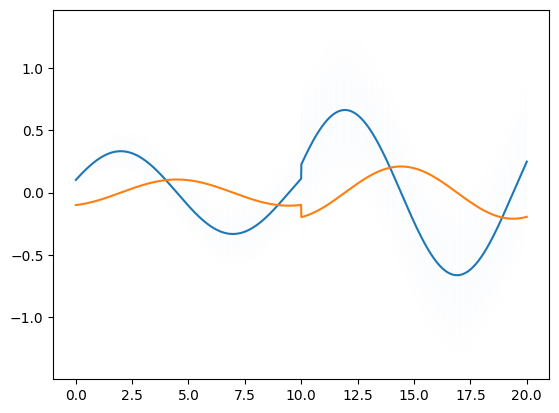

In [318]:
plt.plot(ts[1:],mean[:,0])
plt.fill_between(ts[1:], mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts[1:],mean[:,1])
#plt.fill_between(ts[1:], states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)

In [204]:
from probjax.inference.filtering.unscented_kalman_filter import ukf

In [205]:

dt = 0.01
transition_matrix, transtion_cov = matrix_fraction_decomposition(0,dt,A, B)


def transition_fn(x, t_old, t):
    return jnp.dot(transition_matrix, x)

def observation_fn(x, t):
    return jnp.dot(C, x)


In [206]:
ts[1]- ts[0]

Array(0.010005, dtype=float64)

In [268]:
from probjax.inference.filtering.unscented_kalman_filter import merwe_sigma_point

kernel = ukf(transition_fn, transtion_cov, observation_fn, D, sigma_point_fn=merwe_sigma_point)

In [269]:
mu0 = mu0.astype(jnp.float64)
C0 = C0.astype(jnp.float64)

In [270]:
state = kernel.init(mu0, C0)

In [271]:
ts = jnp.linspace(0, 20, 2000)
states, info = filter(jax.random.PRNGKey(0), ts,ts[1000:1001], jnp.array([0.,0.]), kernel, mu0, C0)

In [272]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

In [273]:
std

Array([[[ 0.31644275,  0.        ],
        [-0.00569093,  0.31632896]],

       [[ 0.3168224 ,  0.        ],
        [-0.01136869,  0.31626565]],

       [[ 0.31746732,  0.        ],
        [-0.01699563,  0.31593849]],

       ...,

       [[ 0.44487898,  0.        ],
        [-0.00571941,  0.26627643]],

       [[ 0.44511953,  0.        ],
        [-0.00571949,  0.26638747]],

       [[ 0.44535999,  0.        ],
        [-0.00571957,  0.26649846]]], dtype=float64)

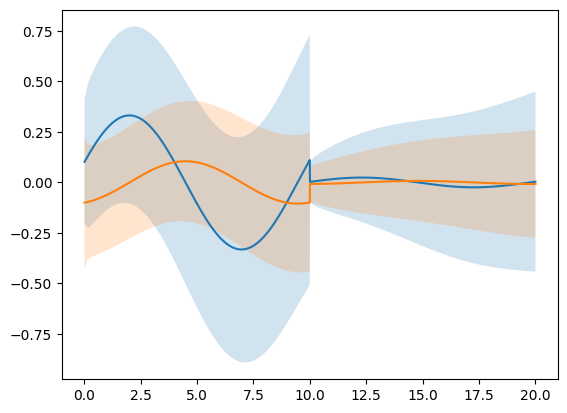

In [274]:
plt.plot(ts[1:],mean[:,0])
plt.fill_between(ts[1:], mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts[1:],mean[:,1])
plt.fill_between(ts[1:], states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)